In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
df = pd.read_csv("breast-cancer.csv")

# Remove unnecessary columns
df.drop(columns=["id"], inplace=True)

# Convert diagnosis to numeric
df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

print(df.head())

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          

In [8]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [11]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


In [12]:
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]


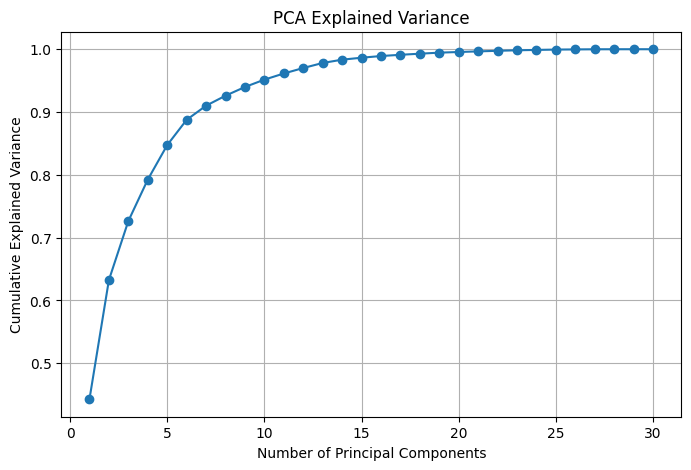

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [14]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape :", X_scaled.shape)
print("Reduced Shape :", X_pca.shape)

Original Shape : (569, 30)
Reduced Shape : (569, 10)


In [15]:
print("Number of Components:")

print(pca.n_components_)

Number of Components:
10


In [16]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

pca_df["Diagnosis"] = y.values

print(pca_df.head())

        PC1        PC2       PC3       PC4       PC5       PC6       PC7  \
0  9.192837   1.948583 -1.123166 -3.633731  1.195110  1.411424  2.159370   
1  2.387802  -3.768172 -0.529293 -1.118264 -0.621775  0.028656  0.013358   
2  5.733896  -1.075174 -0.551748 -0.912083  0.177086  0.541452 -0.668166   
3  7.122953  10.275589 -3.232790 -0.152547  2.960878  3.053422  1.429911   
4  3.935302  -1.948072  1.389767 -2.940639 -0.546747 -1.226495 -0.936213   

        PC8       PC9      PC10  Diagnosis  
0 -0.398407 -0.157118 -0.877402          1  
1  0.240988 -0.711905  1.106995          1  
2  0.097374  0.024066  0.454275          1  
3  1.059565 -1.405440 -1.116975          1  
4  0.636376 -0.263805  0.377704          1  


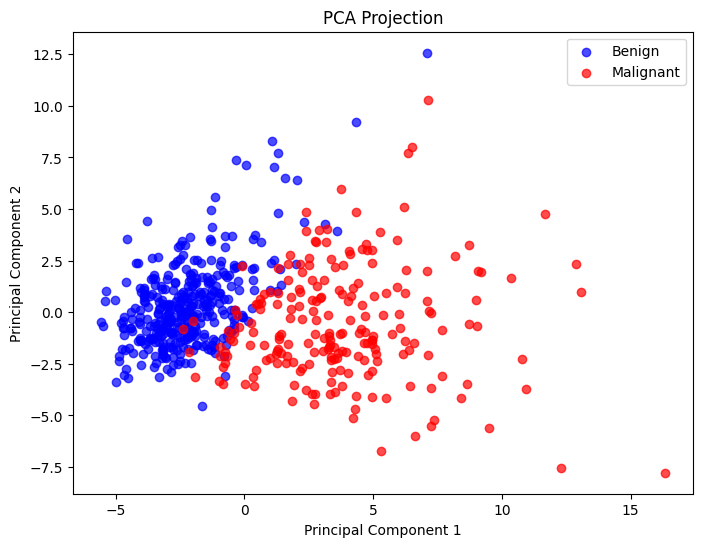

In [17]:
plt.figure(figsize=(8,6))

colors = ['blue', 'red']

for diagnosis, color in zip([0,1], colors):

    subset = pca_df[pca_df["Diagnosis"] == diagnosis]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        c=color,
        label=("Benign" if diagnosis==0 else "Malignant"),
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection")

plt.legend()

plt.show()

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns
)

print(loadings)

                              PC1       PC2       PC3       PC4       PC5  \
radius_mean              0.218902 -0.233857 -0.008531 -0.041409 -0.037786   
texture_mean             0.103725 -0.059706  0.064550  0.603050  0.049469   
perimeter_mean           0.227537 -0.215181 -0.009314 -0.041983 -0.037375   
area_mean                0.220995 -0.231077  0.028700 -0.053434 -0.010331   
smoothness_mean          0.142590  0.186113 -0.104292 -0.159383  0.365089   
compactness_mean         0.239285  0.151892 -0.074092 -0.031795 -0.011704   
concavity_mean           0.258400  0.060165  0.002734 -0.019123 -0.086375   
concave points_mean      0.260854 -0.034768 -0.025564 -0.065336  0.043861   
symmetry_mean            0.138167  0.190349 -0.040240 -0.067125  0.305941   
fractal_dimension_mean   0.064363  0.366575 -0.022574 -0.048587  0.044424   
radius_se                0.205979 -0.105552  0.268481 -0.097941  0.154456   
texture_se               0.017428  0.089980  0.374634  0.359856  0.191651   

In [19]:
pc1_importance = loadings["PC1"].abs().sort_values(ascending=False)

print(pc1_importance)

concave points_mean        0.260854
concavity_mean             0.258400
concave points_worst       0.250886
compactness_mean           0.239285
perimeter_worst            0.236640
concavity_worst            0.228768
radius_worst               0.227997
perimeter_mean             0.227537
area_worst                 0.224871
area_mean                  0.220995
radius_mean                0.218902
perimeter_se               0.211326
compactness_worst          0.210096
radius_se                  0.205979
area_se                    0.202870
concave points_se          0.183417
compactness_se             0.170393
concavity_se               0.153590
smoothness_mean            0.142590
symmetry_mean              0.138167
fractal_dimension_worst    0.131784
smoothness_worst           0.127953
symmetry_worst             0.122905
texture_worst              0.104469
texture_mean               0.103725
fractal_dimension_se       0.102568
fractal_dimension_mean     0.064363
symmetry_se                0

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9649122807017544
[[72  0]
 [ 4 38]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

